# **Raw Audio AutoEncoder Training Notebook**

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchmetrics
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio

import torchaudio

from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import gc
import os
import sys
import cpuinfo
import platform
import time

import net

gc.enable()

gc.collect()

20

## Helper Functions

In [2]:
# Function for measuring the time it takes for a model to process a given input. CPU Only, measuring on GPU might be inaccurate.
@torch.inference_mode()
def count_time(model, x, reps=10, warm_up=(True, 5)):
    if warm_up[0]:
        for i in range(warm_up[1]):
            _ = model(x)

    times = []
    for i in range(reps):
        start = time.perf_counter_ns()
        _ = model(x)
        times.append(time.perf_counter_ns() - start)

    return {
        'mean': sum(times) / len(times),
        'max': max(times), 'min': min(times),
        'std': (sum((t - sum(times)/len(times))**2 for t in times) / len(times))**0.5
    }

In [3]:
# This is copy-pasted directly from the source code of the main function of cpuinfo but with some parameters removed.
def print_cpuinfo():
    info = cpuinfo.get_cpu_info()
    print('CPU INFO:')
    print('  Vendor ID Raw: {0}'.format(info.get('vendor_id_raw', '')))
    print('  Brand Raw: {0}'.format(info.get('brand_raw', '')))
    print('  Number of Online Logical CPUs: {0}'.format(os.cpu_count())) # <-- I added this
    print('  Arch: {0}'.format(info.get('arch', '')))
    print('  Bits: {0}'.format(info.get('bits', '')))
    print('  L1 Data Cache Size: {0}'.format(info.get('l1_data_cache_size', '')))
    print('  L2 Cache Size: {0}'.format(info.get('l2_cache_size', '')))
    print('  L3 Cache Size: {0}'.format(info.get('l3_cache_size', '')))

In [4]:
def load_dataset(val_samples=1024, test_samples=50):
    data = torch.load("dataset.pt")

    num_samples = len(data)
    # Every sample in the dataset is picked at random, and I use shuffle=True in the DataLoader.
    # but I put a random permutation here anyway for more randomness
    ids = torch.randperm(num_samples)
    data = data[ids]

    gc.collect()

    train_dataset = TensorDataset(data[:-val_samples])
    val_dataset = TensorDataset(data[-val_samples:])
    test_data = data[-test_samples:]

    gc.collect()

    return train_dataset, val_dataset, test_data, num_samples

#### **Loss Function**
$$
\mathcal{L}(x, y) = (\mathrm{S}(x) - \mathrm{S}(y))^2
$$
, where $S(x)=STFT(x)$, $x$ is prediction and $y$ is target

**Note:** _I'm using `return_complex=True` and `torch.view_as_real` because of a deprecation warning._

In [5]:
class FFTLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.n_fft = 256
        self.window = torch.hann_window(self.n_fft, periodic=True, requires_grad=False)

    def forward(self, preds, target):
        preds = torch.view_as_real(torch.stft(preds, self.n_fft, window=self.window, return_complex=True))
        target = torch.view_as_real(torch.stft(target, self.n_fft, window=self.window, return_complex=True))
        return F.mse_loss(preds, target)

## Training

In [6]:
metrics = {
    "train_loss": [float('inf')], "val_loss": [float('inf')],
    "train_snr": [float('-inf')], "val_snr": [float('-inf')],
    "grad_norm": [float('inf')], "max_steps": 0.0
}

def train(model, train_dataset: TensorDataset, val_dataset: TensorDataset,
          epochs: int = 1, eval_interval: int = 5, pbar_update_interval: int = 2, snr_interval: int = 2,
          batch_size: int = 32, lr: float = 6e-4, betas: tuple = (0.9, 0.995), weight_decay: float = 1e-4,
          grad_clip: float = 2.5, device: str = 'cuda', criterion: Any = nn.L1Loss):

    model.train()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=1)

    criterion = criterion()
    snr = ScaleInvariantSignalNoiseRatio()
    optimizer = optim.AdamW(model.parameters(), lr=lr, betas=betas, weight_decay=weight_decay)

    epoch = 0
    max_steps = len(train_loader)
    metrics["max_steps"] = metrics["max_steps"] + (max_steps*epochs)

    gc.collect()

    while epoch < epochs:
        pbar = tqdm(train_loader, desc=f"Training Epoch {epoch}")
        for batch_idx, batch in enumerate(pbar):
            batch = batch[0]

            model.train()

            optimizer.zero_grad()

            output = model(batch)
            loss = criterion(output, batch)

            train_snr = None
            if batch_idx % snr_interval == 0:
                with torch.no_grad():
                    train_snr = snr(output, batch)
                metrics["train_snr"].append(train_snr)

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            metrics["train_loss"].append(loss.item())
            metrics["grad_norm"].append(grad_norm)

            if batch_idx % pbar_update_interval == 0:
                pbar.set_postfix({
                    "train_loss": f"{loss.item():.6f}",
                    "val_loss": f"{metrics['val_loss'][-1]:.6f}",
                    "train_snr": f"{metrics['train_snr'][-1]:.6f}",
                    "val_snr": f"{metrics['val_snr'][-1]:.6f}",
                    "grad_norm": f"{grad_norm:.6f}"
                })

            if batch_idx % eval_interval == 0 or batch_idx == max_steps - 1:
                model.eval()
                val_losses, val_snrs = [], []
                with torch.no_grad():
                    for val_batch in val_loader:
                        val_batch = val_batch[0]
                        val_out = model(val_batch)
                        val_losses.append(criterion(val_out, val_batch).item())
                        val_snrs.append(snr(val_out, val_batch))

                avg_val_loss = np.mean(val_losses)
                avg_val_snr = np.mean(val_snrs)
                
                metrics["val_loss"].append(avg_val_loss)
                metrics["val_snr"].append(avg_val_snr)
                
                pbar.set_postfix({
                    "train_loss": f"{loss.item():.6f}",
                    "val_loss": f"{avg_val_loss:.6f}",
                    "train_snr": f"{metrics['train_snr'][-1]:.6f}",
                    "val_snr": f"{avg_val_snr:.6f}",
                    "grad_norm": f"{grad_norm:.6f}",
                })

        gc.collect()

        epoch += 1

### Config

In [7]:
seed = 123
epochs = 3
eval_interval = 16
pbar_update_interval = 1
snr_interval = 2
batch_size=32
lr = 6e-4
weight_decay = 1e-2
grad_clip = 3.5

betas = (0.9, 0.995)

num_threads = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

#### Dataset Loading

In [8]:
val_samples, test_samples = 128, 64

print("Loading Dataset")
train_dataset, val_dataset, test_data, num_samples = load_dataset(val_samples, test_samples)

print(f"Dataset: num_samples: {num_samples}")

Loading Dataset
Dataset: num_samples: 8320


In [9]:
print(f"Running on: {device}")
print_cpuinfo()
print(f"PyTorch version: {torch.__version__}")
print(f"Platform: {platform.platform()}")
print(f"Date: {time.asctime()}")

Running on: cpu
CPU INFO:
  Vendor ID Raw: AuthenticAMD
  Brand Raw: AMD Ryzen 7 5700U with Radeon Graphics
  Number of Online Logical CPUs: 16
  Arch: X86_64
  Bits: 64
  L1 Data Cache Size: 262144
  L2 Cache Size: 4194304
  L3 Cache Size: 524288
PyTorch version: 2.8.0+cpu
Platform: Linux-6.19.11+kali-amd64-x86_64-with-glibc2.42
Date: Tue Jul 28 12:55:31 2026


#### Model Initialization

In [10]:
model = net.AutoEncoder()
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Parameters: 181277


### **Model Training**

In [11]:
torch.set_num_threads(num_threads)
train(model, train_dataset, val_dataset, epochs=epochs,
      eval_interval=eval_interval, pbar_update_interval=pbar_update_interval,
      snr_interval=snr_interval, batch_size=batch_size, lr=lr, betas=betas,
      weight_decay=weight_decay, grad_clip=grad_clip,device=device, criterion=FFTLoss)
model.eval()

time_at_end_of_training = time.asctime()

print(f"TRAINING COMPLETED, date: {time_at_end_of_training}")

Training Epoch 0:   0%|                                                                                                               | 0/256 [00:00<?, ?it/s]/root/virtual/lib/python3.13/site-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1027.)
  return F.conv1d(
Training Epoch 2: 100%|█| 256/256 [48:16<00:00, 11.32s/it, train_loss=0.265290, val_loss=0.277120, train_snr=11.175085, val_snr=10.597783, grad_norm=9.056244]


TRAINING COMPLETED, date: Tue Jul 28 15:13:29 2026


#### Save Model

In [12]:
torch.save(model, 'autoencoder.pt')

### Plots

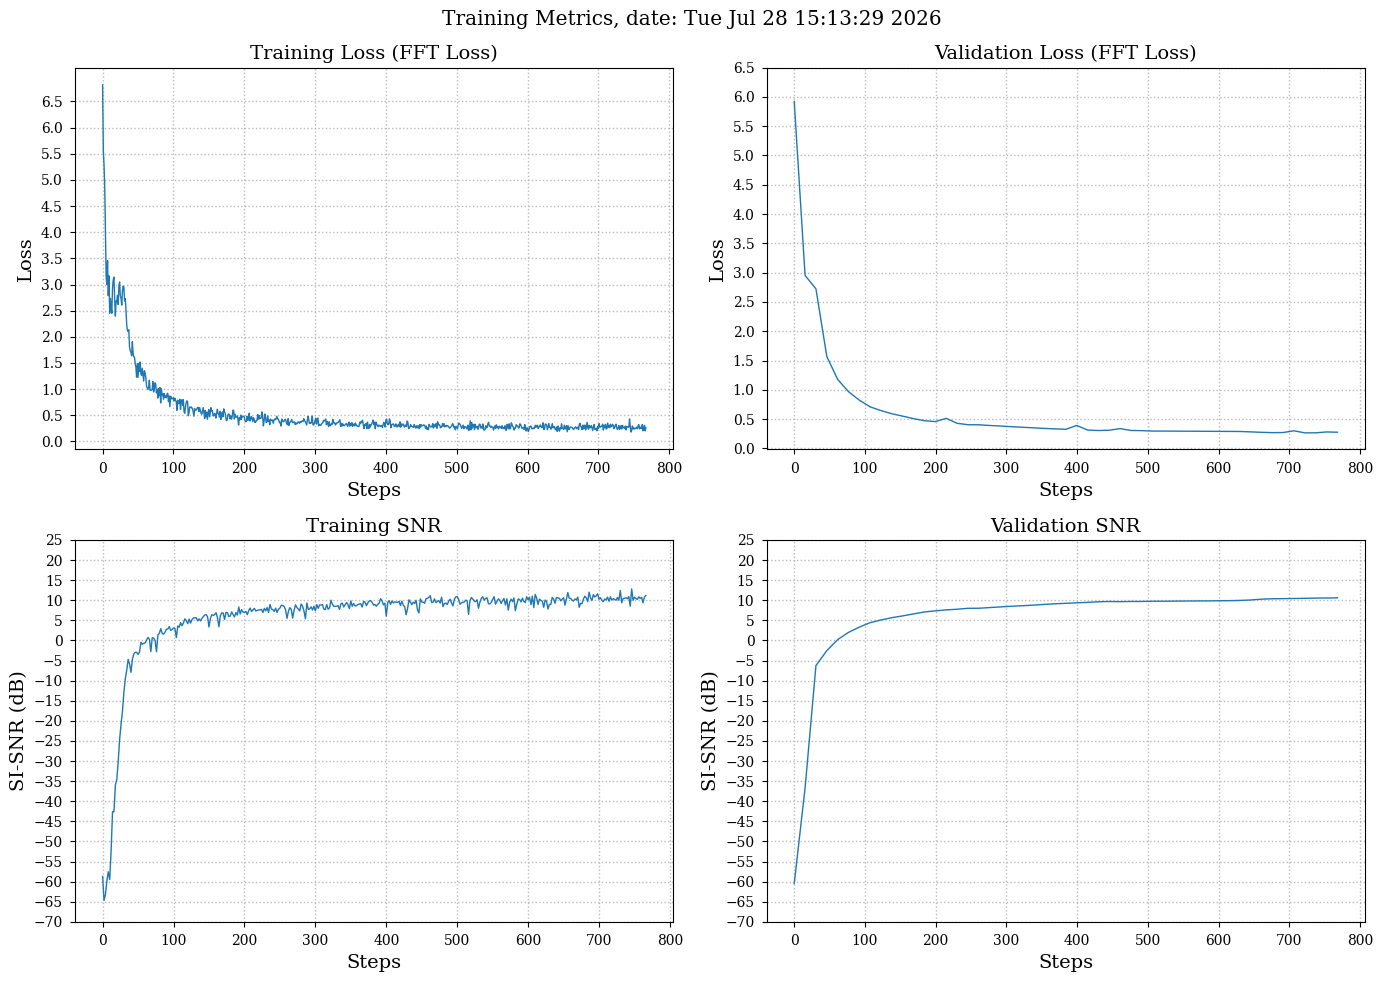

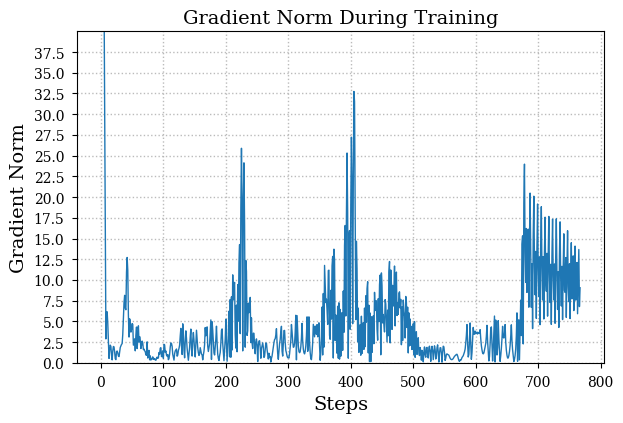

In [14]:
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'grid.alpha': 0.85,
    'grid.linewidth': 1.0,
    'grid.linestyle': ':'
})

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(f"Training Metrics, date: {time_at_end_of_training}")

# Train Loss
axs[0, 0].plot(torch.arange(metrics["max_steps"]), metrics["train_loss"][1:], linewidth=1.0)
axs[0, 0].set_yticks(np.arange(0, 7.0, 0.5))

# Val Loss
axs[0, 1].plot(torch.linspace(0, int(metrics["max_steps"]), int(metrics["max_steps"]//eval_interval)+epochs), metrics["val_loss"][1:], linewidth=1)
axs[0, 1].set_yticks(np.arange(0, 7.0, 0.5))

# Train SI-SNR
axs[1, 0].plot(torch.arange(metrics["max_steps"]//snr_interval)*snr_interval, metrics["train_snr"][1:], linewidth=1.0)
axs[1, 0].set_yticks(np.arange(-70, 30, 5))

# Val SI-SNR
axs[1, 1].plot(torch.linspace(0, int(metrics["max_steps"]), int(metrics["max_steps"]//eval_interval+epochs)), metrics["val_snr"][1:], linewidth=1)
axs[1, 1].set_yticks(np.arange(-70, 30, 5))

axs[0, 0].set_title('Training Loss (FFT Loss)', fontsize=14)
axs[0, 0].set_xlabel('Steps')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)

axs[0, 1].set_title('Validation Loss (FFT Loss)', fontsize=14)
axs[0, 1].set_xlabel('Steps')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].grid(True)

axs[1, 0].set_title('Training SNR', fontsize=14)
axs[1, 0].set_xlabel('Steps')
axs[1, 0].set_ylabel('SI-SNR (dB)')
axs[1, 0].grid(True)

axs[1, 1].set_title('Validation SNR', fontsize=14)
axs[1, 1].set_xlabel('Steps')
axs[1, 1].set_ylabel('SI-SNR (dB)')
axs[1, 1].grid(True)

plt.tight_layout()
plt.savefig('Training_Metrics_RawAudio_AutoEncoder.png', bbox_inches='tight', dpi=400)
plt.show()

plt.plot(torch.arange(metrics["max_steps"]), metrics["grad_norm"][1:], linewidth=1)
plt.title('Gradient Norm During Training', fontsize=14)
plt.xlabel('Steps')
plt.ylabel('Gradient Norm')
plt.yticks(np.arange(0, 40, 2.5))
plt.ylim((0, 40))
plt.grid(True)
plt.tight_layout()
plt.savefig('Training_Metrics_RawAudio_AutoEncoder_grad_norm.png', bbox_inches='tight', dpi=150)
plt.show()

### Metric Statistics

In [15]:
train_loss = torch.tensor(metrics['train_loss'][1:])
train_snr = torch.tensor(metrics['train_snr'][1:])
val_loss = torch.tensor(metrics['val_loss'][1:])
val_snr = torch.tensor(metrics['val_snr'][1:])

stats = (val_loss.min(dim=-1), val_loss.max(dim=-1),
         val_snr.max(dim=-1), val_snr.min(dim=-1),
         train_loss.min(dim=-1), train_loss.max(dim=-1),
         train_snr.max(dim=-1), train_snr.min(dim=-1),
         val_loss.mean(dim=-1), val_loss.std(dim=-1),
         train_loss.mean(dim=-1), train_loss.std(dim=-1),
         val_snr.mean(dim=-1), val_snr.std(dim=-1),
         train_snr.mean(dim=-1), train_snr.std(dim=-1)
        )

print(f"Max Steps: {metrics["max_steps"]}")
print(f"  Best Val Loss: {stats[0].values:.6f} at step {stats[0].indices}")
print(f"  Worst Val Loss: {stats[1].values:.6f} at step {stats[1].indices}")
print(f"  Best Val SNR: {stats[2].values:.6f} at step {stats[2].indices}")
print(f"  Worst Val SNR: {stats[3].values:.6f} at step {stats[3].indices}")
print(f"  Best Train Loss: {stats[4].values:.6f} at step {stats[4].indices}")
print(f"  Worst Train Loss: {stats[5].values:.6f} at step {stats[5].indices}")
print(f"  Best Train SNR: {stats[6].values:.6f} at step {stats[6].indices}")
print(f"  Worst Train SNR: {stats[7].values:.6f} at step {stats[7].indices}")
print(f"  Mean Val Loss: {stats[8]:.6f} +- {stats[9]:.6f}")
print(f"  Mean Train Loss: {stats[10]:.6f} +- {stats[11]:.6f}")
print(f"  Mean Val SNR: {stats[12]:.6f} +- {stats[13]:.6f}")
print(f"  Mean Train SNR: {stats[14]:.6f} +- {stats[15]:.6f}")
print(f"  Last Val Loss: {val_loss[-1]:.6f}, Last Train Loss: {train_loss[-1]:.6f}, Last Val SNR: {val_snr[-1]:.6f}, Last Train SNR: {train_snr[-1]:.6f}")

Max Steps: 768.0
  Best Val Loss: 0.266287 at step 47
  Worst Val Loss: 5.922158 at step 0
  Best Val SNR: 10.597783 at step 50
  Worst Val SNR: -60.508865 at step 0
  Best Train Loss: 0.178382 at step 746
  Worst Train Loss: 6.815821 at step 0
  Best Train SNR: 12.813047 at step 373
  Worst Train SNR: -64.704971 at step 1
  Mean Val Loss: 0.629468 +- 0.924711
  Mean Train Loss: 0.547888 +- 0.667091
  Mean Val SNR: 5.735171 +- 11.835320
  Mean Train SNR: 5.733616 +- 11.166528
  Last Val Loss: 0.277120, Last Train Loss: 0.265290, Last Val SNR: 10.597783, Last Train SNR: 11.175085


Elapsed Time on 60 seconds of audio at 24Khz: {'mean': 1292668889.8, 'max': 1299874652, 'min': 1284592672, 'std': 5681824.764299033}
 mean seconds: 1.2926688898
The model is 46.42x faster than real time at 24Khz for 60 seconds of audio


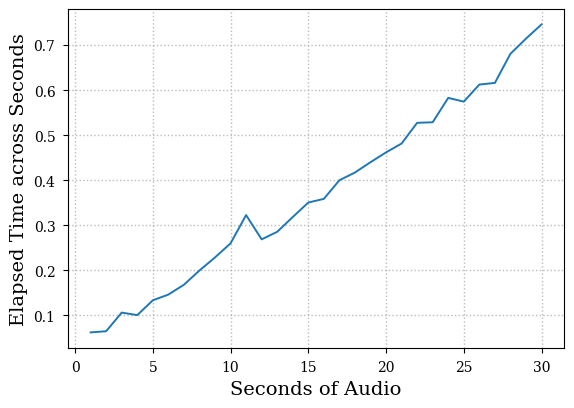

In [17]:
elapsed = count_time(model, torch.randn(1, 24000*60), reps=5, warm_up=(True, 3))
print(f"Elapsed Time on 60 seconds of audio at 24Khz: {elapsed}\n mean seconds: {elapsed['mean']/1_000_000_000}")
print(f"The model is {(60 / (elapsed['mean']/1_000_000_000)):.2f}x faster than real time at 24Khz for 60 seconds of audio")

seconds = 30

time_ns = []
for i in range(seconds):
    time_ns.append(count_time(model, torch.randn(1, 24000*(i+1)), reps=3, warm_up=(False, 0))['mean']/1_000_000_000)
plt.plot(torch.arange(1, seconds+1), torch.tensor(time_ns))
plt.xlabel('Seconds of Audio')
plt.ylabel('Elapsed Time across Seconds')
plt.grid(True)
plt.savefig("Time_across_seconds.png", dpi=80)
plt.show()

In [18]:
audio, fr = torchaudio.load('data/Avicii - Hey Brother(MP3_160K).mp3') # <-- 48000Khz, ~3 minutes

/root/virtual/lib/python3.13/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


In [19]:
start = time.perf_counter_ns()
with torch.inference_mode():
    y = model(audio[0].unsqueeze(0))
elapsed_ns = time.perf_counter_ns() - start
print(f"Seconds: {elapsed_ns/1_000_000_000}")

Seconds: 16.17130297


In [20]:
# Save 120 seconds of audio
torchaudio.save('audio_sample_original_48Khz_30s.mp3', audio[0, :48000*120].unsqueeze(0), 48000)
torchaudio.save('audio_sample_reconstructed_48Khz_30s.mp3', y[:, :48000*120], 48000)

/root/virtual/lib/python3.13/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(


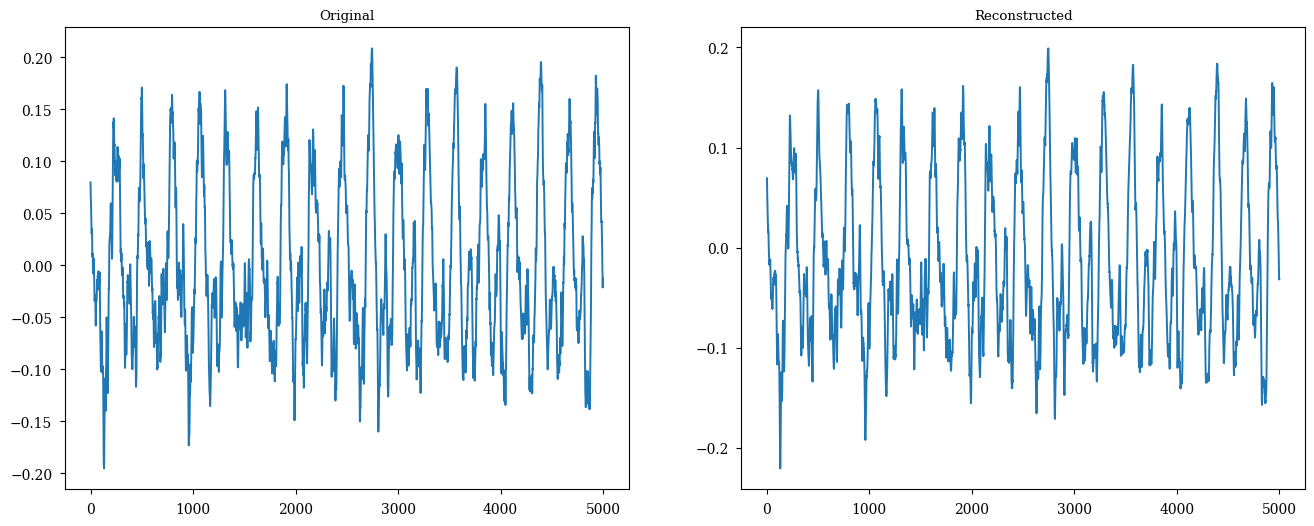

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(audio[0, (fr*10)-5000:(fr*10)])
axs[1].plot(y[0, (fr*10)-5000:(fr*10)])

axs[0].set_title("Original")
axs[1].set_title("Reconstructed")

plt.savefig('sample1.png')

plt.show()

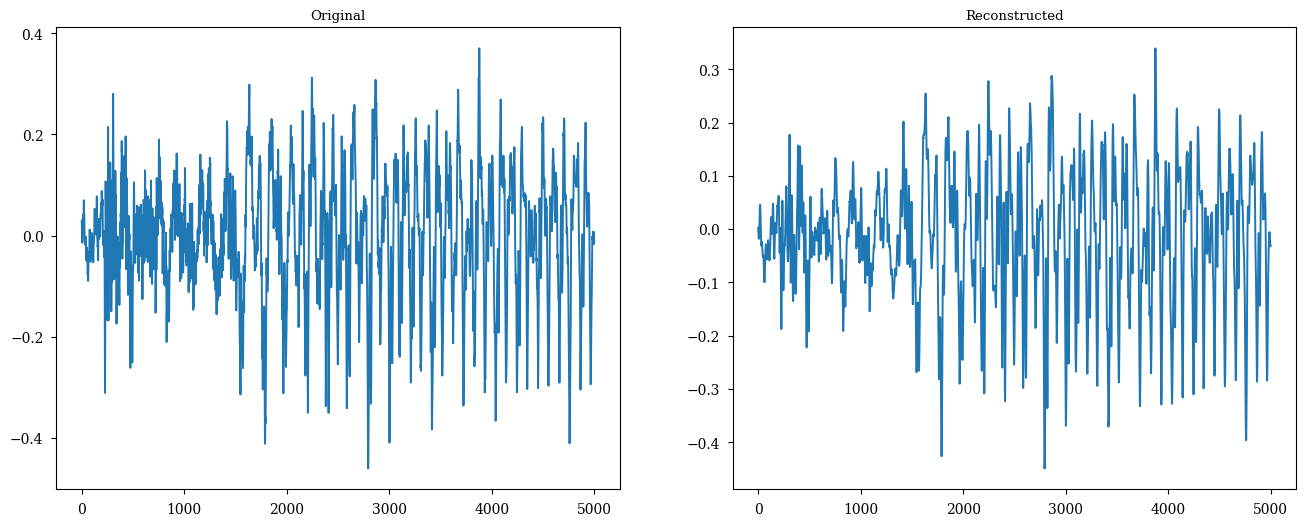

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(audio[0, (fr*20)-5000:(fr*20)])
axs[1].plot(y[0, (fr*20)-5000:(fr*20)])

axs[0].set_title("Original")
axs[1].set_title("Reconstructed")

plt.savefig('sample2.png')

plt.show()

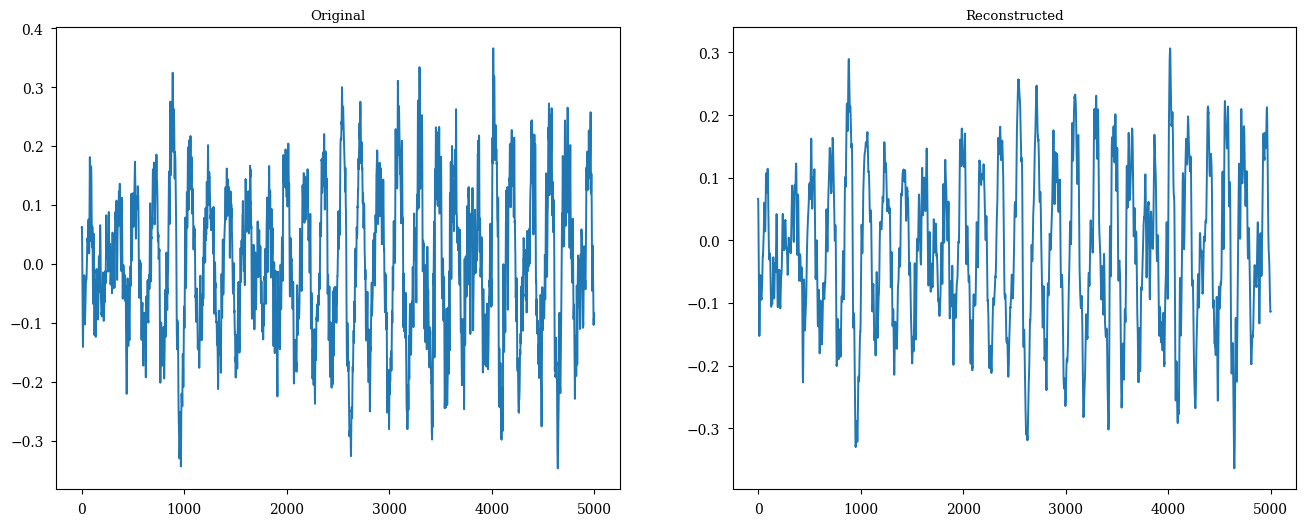

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(audio[0, (fr*30)-5000:(fr*30)])
axs[1].plot(y[0, (fr*30)-5000:(fr*30)])

axs[0].set_title("Original")
axs[1].set_title("Reconstructed")

plt.savefig('sample3.png')

plt.show()

### Test SI-SNR

Evaluating on 24Khz audio: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 512/512 [01:14<00:00,  6.89it/s]


Scale Invariant Signal Noise Ratio (SI-SNR): 10.279277801513672


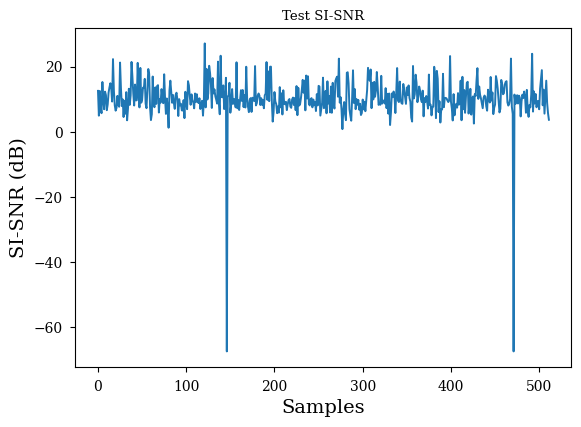

Evaluating on 48Khz audio: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 512/512 [02:36<00:00,  3.26it/s]


Scale Invariant Signal Noise Ratio (SI-SNR): 14.06658935546875


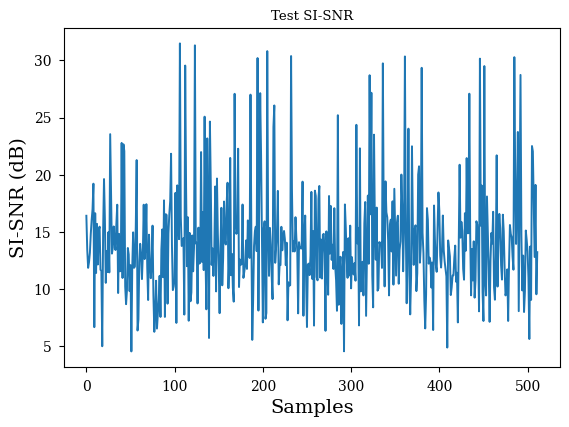

In [27]:
data_24khz = torch.load('test_dataset_24khz.pt')
data_48khz = torch.load('test_dataset_48khz.pt')

si_snr = ScaleInvariantSignalNoiseRatio()

values = []

@torch.inference_mode()
def eval_snr(data: torch.Tensor, fr: str, info: str):
    
    values = []
    for sample in tqdm(data, desc=info):
        values.append(si_snr(model(sample.unsqueeze(0)), sample.unsqueeze(0)))
    print(f"Scale Invariant Signal Noise Ratio (SI-SNR): {np.mean(values)}")

    plt.plot(values)
    plt.title('Test SI-SNR')
    plt.xlabel('Samples')
    plt.ylabel('SI-SNR (dB)')
    plt.savefig(f"SI-SNR_{fr}.png", bbox_inches='tight', dpi=120)
    plt.show()

values_24khz = eval_snr(data_24khz, "24Khz", "Evaluating on 24Khz audio")
values_48khz = eval_snr(data_48khz, "48Khz", "Evaluating on 48Khz audio")

In [28]:
print(f"Number of Conv1d in Encoder: {sum(1 for module in model.enc.modules() if isinstance(module, nn.Conv1d))}")
print(f"Number of Conv1d in Decoder: {sum(1 for module in model.dec.modules() if isinstance(module, nn.Conv1d))}")
print(f"Number of ConvTranspose1d in Decoder: {sum(1 for module in model.dec.modules() if isinstance(module, nn.ConvTranspose1d))}")
print(f"Number of EncoderBlock in Encoder: {sum(1 for module in model.enc.modules() if isinstance(module, net.EncoderBlock))}")
print(f"Number of DecoderBlock in Decoder: {sum(1 for module in model.dec.modules() if isinstance(module, net.DecoderBlock))}")
print(f"Total submodules in model: {sum(1 for module in model.modules() if isinstance(module, nn.Module))}")

Number of Conv1d in Encoder: 31
Number of Conv1d in Decoder: 23
Number of ConvTranspose1d in Decoder: 6
Number of EncoderBlock in Encoder: 5
Number of DecoderBlock in Decoder: 6
Total submodules in model: 141


In [31]:
print(f"Total submodules in model without counting activation functions: {sum(1 for module in model.modules() if isinstance(module, nn.Module))-sum(1 for module in model.modules() if isinstance(module, net.Snake))}")

Total submodules in model without counting activation functions: 135


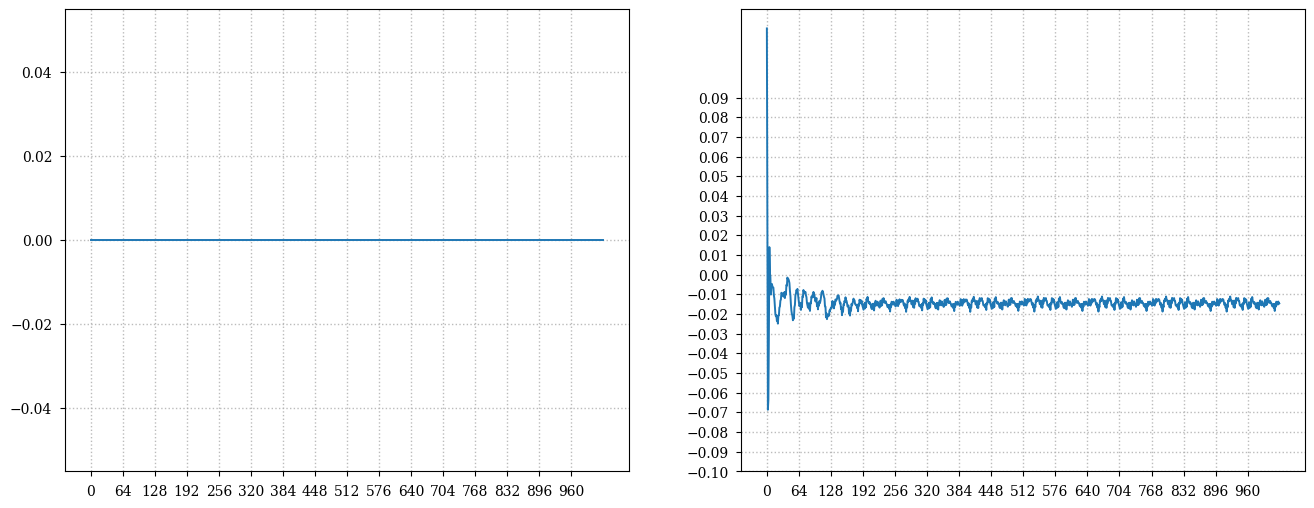

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].plot(audio[0, :1024])
axs[1].plot(y[0, :1024])

axs[0].set_xticks(np.arange(0, 1024, 64))
axs[0].grid(True)

axs[1].set_yticks(np.arange(-0.1, 0.1, 0.01))
axs[1].set_xticks(np.arange(0, 1024, 64))
axs[1].grid(True)

plt.show()

In [29]:
print("======================================================")
print("===================    METRICS    ====================")
print("======================================================")

print(f"TRAIN LOSS: {metrics["train_loss"]}\n\n")
print(f"VAL LOSS: {torch.tensor(metrics["val_loss"]).tolist()}\n\n")
print(f"TRAIN SNR: {torch.tensor(metrics["train_snr"]).tolist()}\n\n")
print(f"VAL SNR: {torch.tensor(metrics["val_snr"]).tolist()}\n\n")
print(f"GRADIENT NORM: {torch.tensor(metrics["grad_norm"]).tolist()}\n\n")

===================    METRICS    ====================
TRAIN LOSS: [inf, 6.815821170806885, 5.557895660400391, 5.284360885620117, 4.862218379974365, 3.9546120166778564, 3.1544368267059326, 3.0022568702697754, 3.4550371170043945, 2.786367893218994, 3.1643943786621094, 2.451399087905884, 2.733955144882202, 2.574211597442627, 2.4502623081207275, 2.9390835762023926, 3.085969924926758, 3.1412885189056396, 2.729358673095703, 2.3959641456604004, 2.6832404136657715, 2.671389579772949, 2.7934420108795166, 2.6150527000427246, 2.972245454788208, 3.0484986305236816, 2.780888557434082, 2.7388370037078857, 2.6059231758117676, 2.866199254989624, 2.9710965156555176, 2.949960708618164, 2.686616897583008, 2.7304015159606934, 2.5104947090148926, 2.2358412742614746, 2.12368106842041, 2.1012749671936035, 2.1342668533325195, 1.8088279962539673, 1.7378911972045898, 1.701736330986023, 1.634839653968811, 1.9066358804702759, 1.6909133195877075, 1.6226879358291626, 1.606675386428833, 1.4937580823898315, 1.420572